In [1]:
# ============================================================
# CELL 1: IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# ANALYSIS:
# Pandas is used to load and work with the AAPL dataset.
# NumPy is used for mathematical calculations.
# Matplotlib is used to create graphs.
# Seaborn is used for additional visualization.

In [2]:
# ============================================================
# CELL 2: LOAD DATASET
# ============================================================

df = None

try:
    df = pd.read_csv(
        "/content/drive/MyDrive/MachineLearningModels/Supervised Learning/stockmarketdataset/AAPL.csv"
    )

    print("AAPL dataset loaded successfully.")

except FileNotFoundError:
    print("AAPL.csv was not found at the specified path.")

display(df.head())

# ANALYSIS:
# We load Apple's stock data from the CSV file.
#
# try/except prevents the program from crashing if the file
# cannot be found.
#
# df.head() displays the first 5 rows so we can check
# whether the dataset was loaded correctly.

AAPL dataset loaded successfully.


,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


In [3]:
# ============================================================
# CELL 3: DATASET INFORMATION
# ============================================================

print("Number of rows and columns:")
print(df.shape)

print("\nDataFrame Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

print("\nMissing Values:")
display(df.isnull().sum())

# ANALYSIS:
# df.shape tells us the number of rows and columns.
#
# df.info() shows column names, data types, and
# the number of non-null values.
#
# df.describe() gives statistical information such as
# mean, minimum, maximum and standard deviation.
#
# isnull().sum() tells us how many missing values
# exist in each column.

Number of rows and columns:
(9909, 7)

DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9909 entries, 0 to 9908
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9909 non-null   object 
 1   Open       9909 non-null   float64
 2   High       9909 non-null   float64
 3   Low        9909 non-null   float64
 4   Close      9909 non-null   float64
 5   Adj Close  9909 non-null   float64
 6   Volume     9909 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 542.0+ KB

Statistical Summary:


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Open,High,Low,Close,Adj Close,Volume
count,9909.000000,9909.000000,9909.000000,9909.000000,9909.000000,9.909000e+03
mean,32.606849,32.936079,32.277560,32.618030,30.576570,8.582916e+07
std,58.415759,59.001576,57.883037,58.471899,56.746275,8.597195e+07
min,0.198661,0.198661,0.196429,0.196429,0.155638,3.472000e+05
25%,1.071429,1.089286,1.048571,1.071429,0.917643,3.304230e+07
50%,1.729286,1.758929,1.696429,1.732143,1.466154,5.766490e+07
75%,35.799999,36.265713,35.328571,35.761429,31.042374,1.069992e+08
max,324.739990,327.850006,323.350006,327.200012,327.200012,1.855410e+09



Missing Values:


,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [4]:
# ============================================================
# CELL 4: CONVERT DATE
# ============================================================

df["Date"] = pd.to_datetime(df["Date"])

display(df["Date"].head())

# ANALYSIS:
# The Date column may originally be stored as text.
#
# pd.to_datetime() converts it into a proper datetime format.
#
# This allows us to extract the year, month and day later.

,Date
0,1980-12-12
1,1980-12-15
2,1980-12-16
3,1980-12-17
4,1980-12-18


In [5]:
# ============================================================
# CELL 5: SORT DATA BY DATE
# ============================================================

df = df.sort_values("Date")

df = df.reset_index(drop=True)

display(df.head())


# ANALYSIS:
# Stock data should be arranged chronologically.
#
# sort_values("Date") puts the oldest date first
# and the newest date last.
#
# reset_index() creates a clean numerical index after sorting.

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


In [6]:
# ============================================================
# CELL 6: HANDLE MISSING VALUES
# ============================================================

df = df.ffill()

print("Missing values after forward fill:")

display(df.isnull().sum())

# ANALYSIS:
# ffill() means forward fill.
#
# If a value is missing, pandas uses the previous available
# value to fill it.
#
# This is useful for time-series data because stock prices
# are ordered by date.

Missing values after forward fill:


,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [7]:
# ============================================================
# CELL 7: CREATE DATE FEATURES
# ============================================================

df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month

df["Day"] = df["Date"].dt.day

display(df.head())


# ANALYSIS:
# We extract useful information from the Date column.
#
# Year tells us which year the stock data belongs to.
# Month tells us the month.
# Day tells us the day of the month.
#
# These features can be used by machine-learning models.

,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400,1980,12,12
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200,1980,12,15
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000,1980,12,16
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400,1980,12,17
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400,1980,12,18


In [8]:
# ============================================================
# CELL 8: CALCULATE DAILY RETURN
# ============================================================

df["Daily_Return"] = df["Adj Close"].pct_change()

display(
    df[
        ["Date", "Adj Close", "Daily_Return"]
    ].head(10)
)

# ANALYSIS:
# pct_change() calculates the percentage change from
# one trading day to the next.
#
# Daily Return helps us understand how much the stock
# price changed each day.
#
# Positive value = price increased.
# Negative value = price decreased.

,Date,Adj Close,Daily_Return
0,1980-12-12,0.406782,NaN
1,1980-12-15,0.385558,-0.052174
2,1980-12-16,0.357260,-0.073395
3,1980-12-17,0.366103,0.024752
4,1980-12-18,0.376715,0.028986
5,1980-12-19,0.399707,0.061033
6,1980-12-22,0.419162,0.048673
7,1980-12-23,0.436848,0.042194
8,1980-12-24,0.459840,0.052631
9,1980-12-26,0.502287,0.092308


In [9]:
# ============================================================
# CELL 9: CREATE MOVING AVERAGES
# ============================================================

df["MA_20"] = df["Adj Close"].rolling(window=20).mean()

df["MA_50"] = df["Adj Close"].rolling(window=50).mean()

display(
    df[
        ["Date", "Adj Close", "MA_20", "MA_50"]
    ].tail()
)

# ANALYSIS:
# A moving average smooths out daily price fluctuations.
#
# MA_20 calculates the average price over the previous
# 20 trading days.
#
# MA_50 calculates the average price over the previous
# 50 trading days.
#
# Moving averages help us see the general price trend.

,Date,Adj Close,MA_20,MA_50
9904,2020-03-26,258.440002,264.514500,294.410649
9905,2020-03-27,247.740005,263.233501,293.153393
9906,2020-03-30,254.809998,261.033501,291.959721
9907,2020-03-31,254.289993,259.282001,290.686013
9908,2020-04-01,240.910004,256.190501,289.187804


In [10]:
# ============================================================
# CELL 10: CREATE NEXT-DAY TARGET
# ============================================================

df["Target_Next_Day_Close"] = df["Adj Close"].shift(-1)

display(
    df[
        ["Date", "Adj Close", "Target_Next_Day_Close"]
    ].head()
)

# ANALYSIS:
# Our goal is to predict the next trading day's adjusted
# closing price.
#
# shift(-1) moves the next day's price up to the current row.
#
# Example:
#
# Today Adj Close = $100
# Tomorrow Adj Close = $102
#
# Target_Next_Day_Close for today's row = $102

,Date,Adj Close,Target_Next_Day_Close
0,1980-12-12,0.406782,0.385558
1,1980-12-15,0.385558,0.357260
2,1980-12-16,0.357260,0.366103
3,1980-12-17,0.366103,0.376715
4,1980-12-18,0.376715,0.399707


In [11]:
# ============================================================
# CELL 11: REMOVE MISSING VALUES
# ============================================================

df = df.dropna()

df = df.reset_index(drop=True)

print("Dataset after removing missing values:")

display(df.head())

# ANALYSIS:
# Some features create missing values.
#
# For example, MA_50 needs 50 previous trading days.
# Therefore, the first rows do not have an MA_50 value.
#
# dropna() removes rows containing missing values.
#
# reset_index() creates a clean index again.

Dataset after removing missing values:


,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day,Daily_Return,MA_20,MA_50,Target_Next_Day_Close
0,1981-02-24,0.428571,0.428571,0.424107,0.424107,0.336037,4244800,1981,2,24,-0.035533,0.385912,0.420188,0.357260
1,1981-02-25,0.450893,0.453125,0.450893,0.450893,0.357260,4872000,1981,2,25,0.063158,0.381137,0.419197,0.362566
2,1981-02-26,0.457589,0.459821,0.457589,0.457589,0.362566,2710400,1981,2,26,0.014851,0.377334,0.418737,0.374946
3,1981-02-27,0.473214,0.477679,0.473214,0.473214,0.374946,3690400,1981,2,27,0.034147,0.374946,0.419091,0.376715
4,1981-03-02,0.475446,0.477679,0.475446,0.475446,0.376715,2940000,1981,3,2,0.004717,0.373797,0.419303,0.371409


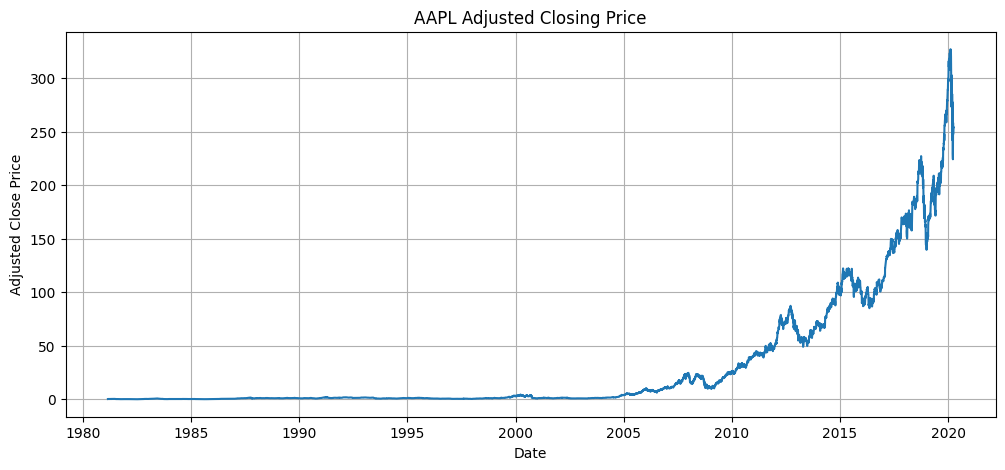

In [12]:
# ============================================================
# CELL 12: AAPL ADJUSTED CLOSING PRICE
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    df["Date"],
    df["Adj Close"]
)

plt.title("AAPL Adjusted Closing Price")

plt.xlabel("Date")

plt.ylabel("Adjusted Close Price")

plt.grid(True)

plt.show()

# ANALYSIS:
# This graph shows how Apple's adjusted closing price
# changed over time.
#
# We can use this graph to observe the overall long-term
# movement and major increases or decreases in price.

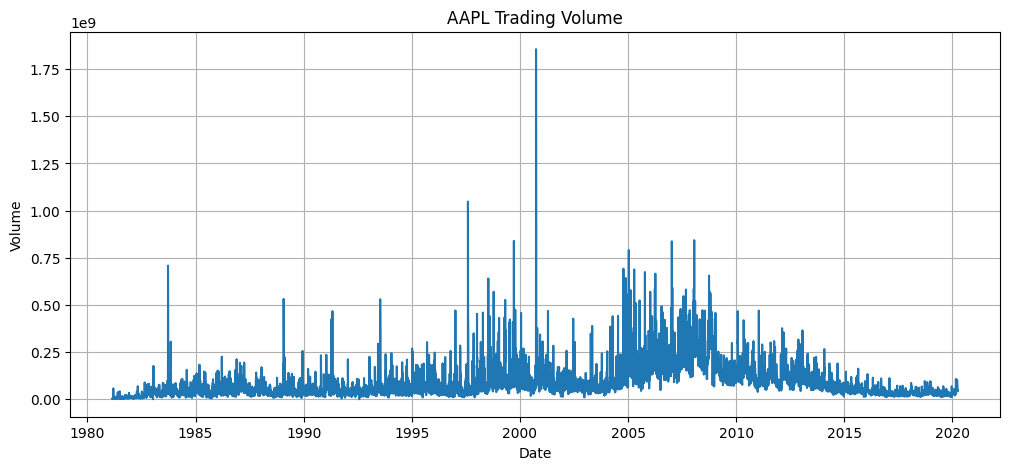

In [13]:
# ============================================================
# CELL 13: AAPL TRADING VOLUME
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    df["Date"],
    df["Volume"]
)

plt.title("AAPL Trading Volume")

plt.xlabel("Date")

plt.ylabel("Volume")

plt.grid(True)

plt.show()

# ANALYSIS:
# Volume represents the number of shares traded.
#
# Large increases in volume can indicate periods when
# many investors were buying or selling the stock.
#
# This helps us understand trading activity.

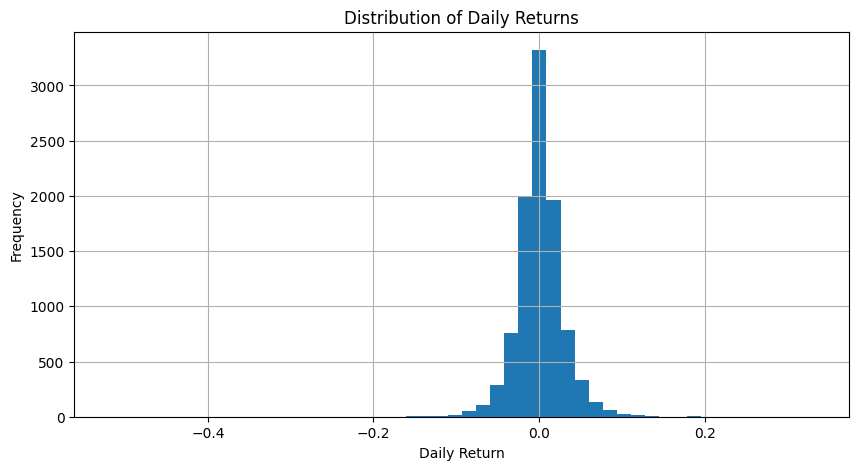

In [14]:
# ============================================================
# CELL 14: DAILY RETURN DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    df["Daily_Return"],
    bins=50
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

# ANALYSIS:
# This histogram shows how Apple's daily returns are
# distributed.
#
# Values near 0 mean the daily price change was small.
#
# Positive values represent gains.
# Negative values represent losses.
#
# The graph also helps us identify unusually large
# daily movements.

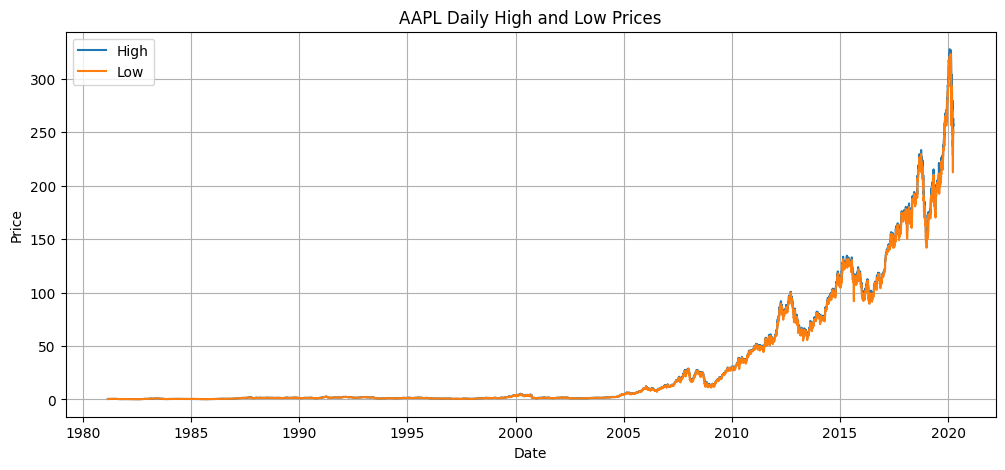

In [15]:
# ============================================================
# CELL 15: DAILY HIGH AND LOW PRICES
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    df["Date"],
    df["High"],
    label="High"
)

plt.plot(
    df["Date"],
    df["Low"],
    label="Low"
)

plt.title("AAPL Daily High and Low Prices")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.grid(True)

plt.show()

# ANALYSIS:
# High represents the highest trading price during a day.
#
# Low represents the lowest trading price during a day.
#
# Comparing these two lines helps us understand the
# daily price range and overall market movement.

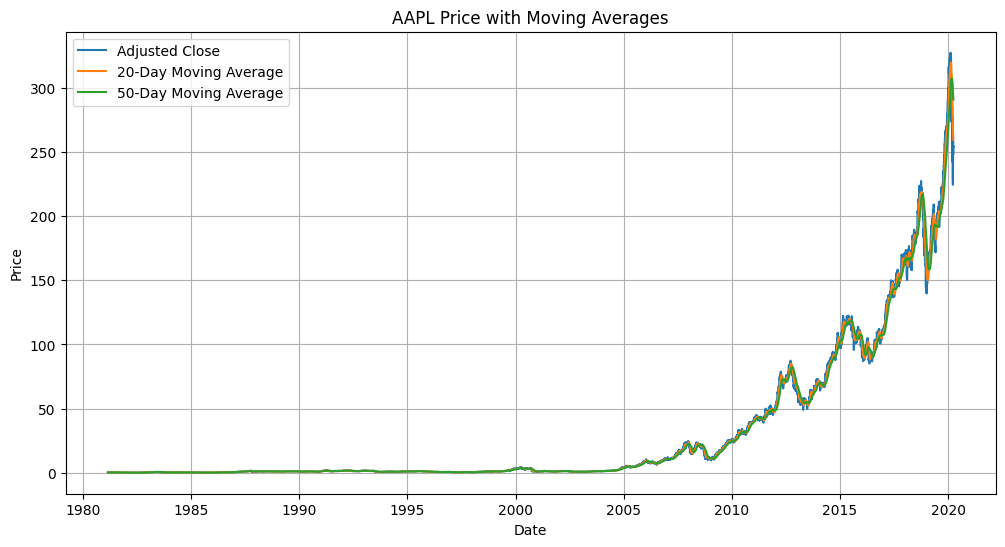

In [16]:
# ============================================================
# CELL 16: MOVING AVERAGES
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    df["Date"],
    df["Adj Close"],
    label="Adjusted Close"
)

plt.plot(
    df["Date"],
    df["MA_20"],
    label="20-Day Moving Average"
)

plt.plot(
    df["Date"],
    df["MA_50"],
    label="50-Day Moving Average"
)

plt.title("AAPL Price with Moving Averages")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.grid(True)

plt.show()


# ANALYSIS:
# The adjusted closing price shows the actual daily movement.
#
# MA_20 shows the shorter-term trend.
#
# MA_50 shows a longer-term trend.
#
# Moving averages make the overall direction easier to see
# because they smooth out daily fluctuations.

In [17]:
# ============================================================
# CELL 17: YEARLY STOCK SUMMARY
# ============================================================

yearly = df.groupby("Year").agg(
    Start_Price=("Adj Close", "first"),
    End_Price=("Adj Close", "last"),
    Highest_Price=("Adj Close", "max"),
    Lowest_Price=("Adj Close", "min"),
    Average_Price=("Adj Close", "mean"),
    Total_Volume=("Volume", "sum")
).reset_index()

display(yearly)

# ANALYSIS:
# groupby("Year") groups all stock records by year.
#
# agg() calculates multiple values for each year.
#
# Start_Price = first adjusted closing price of the year.
# End_Price = last adjusted closing price of the year.
# Highest_Price = highest price during the year.
# Lowest_Price = lowest price during the year.
# Average_Price = average price during the year.
# Total_Volume = total shares traded during the year.

,Year,Start_Price,End_Price,Highest_Price,Lowest_Price,Average_Price,Total_Volume
0,1981,0.336037,0.313045,0.468683,0.201622,0.331517,1832101600
1,1982,0.311276,0.422699,0.479295,0.155638,0.270850,5341252000
2,1983,0.403244,0.344880,0.887845,0.252912,0.530151,11128252800
3,1984,0.362566,0.412087,0.470452,0.309508,0.379218,10494758400
4,1985,0.394401,0.311276,0.433311,0.205159,0.285982,11373068000
5,1986,0.314814,0.573032,0.619015,0.313045,0.459281,13330805600
6,1987,0.578337,1.194453,1.681361,0.578337,1.104276,14942827200
7,1988,1.272662,1.154425,1.349082,1.036113,1.186039,10323244400
8,1989,1.158009,1.020944,1.430359,0.970663,1.200811,12726456400
9,1990,1.078869,1.260885,1.380363,0.730626,1.094436,11100485200


# ANALYSIS:
# groupby("Year") groups all stock records by year.
#
# agg() calculates multiple values for each year.
#
# Start_Price = first adjusted closing price of the year.
# End_Price = last adjusted closing price of the year.
# Highest_Price = highest price during the year.
# Lowest_Price = lowest price during the year.
# Average_Price = average price during the year.
# Total_Volume = total shares traded during the year.

In [18]:
# ============================================================
# CELL 18: CALCULATE YEARLY RETURN
# ============================================================

yearly["Yearly_Return"] = (

    (yearly["End_Price"] - yearly["Start_Price"])
    / yearly["Start_Price"]

) * 100

display(
    yearly[
        [
            "Year",
            "Start_Price",
            "End_Price",
            "Yearly_Return"
        ]
    ]
)

# ANALYSIS:
# This calculates the percentage return for each year.
#
# Formula:
#
# (Ending Price - Starting Price)
# -------------------------------- × 100
#        Starting Price
#
# Positive return = price increased during the year.
#
# Negative return = price decreased during the year.

,Year,Start_Price,End_Price,Yearly_Return
0,1981,0.336037,0.313045,-6.842067
1,1982,0.311276,0.422699,35.795381
2,1983,0.403244,0.344880,-14.473669
3,1984,0.362566,0.412087,13.658567
4,1985,0.394401,0.311276,-21.076180
5,1986,0.314814,0.573032,82.022483
6,1987,0.578337,1.194453,106.532364
7,1988,1.272662,1.154425,-9.290557
8,1989,1.158009,1.020944,-11.836308
9,1990,1.078869,1.260885,16.870929


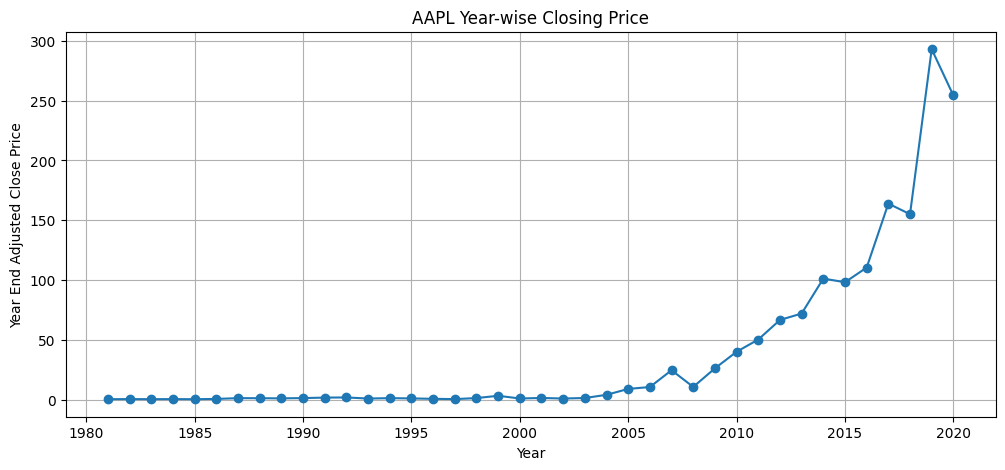

In [19]:
# ============================================================
# CELL 19: YEAR-END PRICE GRAPH
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    yearly["Year"],
    yearly["End_Price"],
    marker="o"
)

plt.title("AAPL Year-wise Closing Price")

plt.xlabel("Year")

plt.ylabel("Year End Adjusted Close Price")

plt.grid(True)

plt.show()

# ANALYSIS:
# This graph shows Apple's adjusted closing price
# at the end of each year.
#
# It makes long-term changes easier to compare
# between different years.

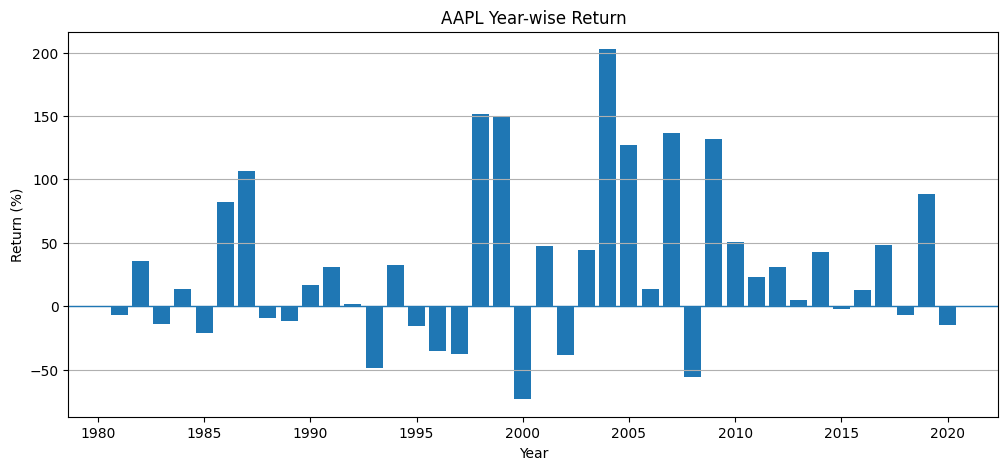

In [20]:
# ============================================================
# CELL 20: YEARLY RETURN GRAPH
# ============================================================

plt.figure(figsize=(12, 5))

plt.bar(
    yearly["Year"],
    yearly["Yearly_Return"]
)

plt.title("AAPL Year-wise Return")

plt.xlabel("Year")

plt.ylabel("Return (%)")

plt.axhline(
    0,
    linewidth=1
)

plt.grid(axis="y")

plt.show()

# ANALYSIS:
# Each bar represents Apple's percentage return for a year.
#
# A positive bar means the ending price was higher
# than the starting price.
#
# A negative bar means the ending price was lower
# than the starting price.

In [21]:
# ============================================================
# CELL 21: INVESTMENT PROFIT / LOSS CALCULATOR
# ============================================================

initial_investment = float(
    input("Enter your investment amount: ")
)

start_year = int(
    input("Enter starting year: ")
)

end_year = int(
    input("Enter ending year: ")
)


# Filter the selected years

year_data = df[
    (df["Year"] >= start_year) &
    (df["Year"] <= end_year)
]


if len(year_data) == 0:

    print("No data found for the selected years.")

else:

    first_price = year_data["Adj Close"].iloc[0]

    last_price = year_data["Adj Close"].iloc[-1]

    shares = initial_investment / first_price

    final_value = shares * last_price

    profit_loss = final_value - initial_investment

    profit_loss_percent = (
        profit_loss / initial_investment
    ) * 100


    print("\nInvestment Analysis")
    print("----------------------------")

    print("Initial Investment:", initial_investment)

    print("Start Year:", start_year)

    print("End Year:", end_year)

    print("First Price:", first_price)

    print("Last Price:", last_price)

    print("Number of Shares:", shares)

    print("Final Value:", final_value)

    print("Profit/Loss:", profit_loss)

    print(
        "Profit/Loss Percentage:",
        profit_loss_percent
    )


# ANALYSIS:
# This cell allows the user to enter an investment amount
# and a range of years.
#
# The program calculates how much the investment would be
# worth based on the first and last adjusted closing prices.
#
# This is a simple historical calculation.
#
# It does NOT include transaction fees, taxes, dividends
# received separately, or other real-world investment costs.

Enter your investment amount: 100
Enter starting year: 2010
Enter ending year: 2020

Investment Analysis
----------------------------
Initial Investment: 100.0
Start Year: 2010
End Year: 2020
First Price: 26.538482666015625
Last Price: 254.2899932861328
Number of Shares: 3.7681129421938264
Final Value: 958.1934147718583
Profit/Loss: 858.1934147718583
Profit/Loss Percentage: 858.1934147718582


In [22]:
# ============================================================
# CELL 22: DEFINE FEATURES AND TARGET
# ============================================================

# Target variable

y = df["Target_Next_Day_Close"]


# Features

X = df[
    [
        "Open",
        "High",
        "Low",
        "Close",
        "Adj Close",
        "Volume",
        "Year",
        "Month",
        "Day",
        "Daily_Return",
        "MA_20",
        "MA_50"
    ]
]


print("Features:")

display(X.head())


print("\nTarget:")

display(y.head())

# ANALYSIS:
# X contains the information that the model will use
# to make a prediction.
#
# y contains the value that we want the model to predict.
#
# In this project:
#
# X = today's stock information
#
# y = next trading day's adjusted closing price
#
# This makes the project a supervised regression problem.

Features:


,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day,Daily_Return,MA_20,MA_50
0,0.428571,0.428571,0.424107,0.424107,0.336037,4244800,1981,2,24,-0.035533,0.385912,0.420188
1,0.450893,0.453125,0.450893,0.450893,0.357260,4872000,1981,2,25,0.063158,0.381137,0.419197
2,0.457589,0.459821,0.457589,0.457589,0.362566,2710400,1981,2,26,0.014851,0.377334,0.418737
3,0.473214,0.477679,0.473214,0.473214,0.374946,3690400,1981,2,27,0.034147,0.374946,0.419091
4,0.475446,0.477679,0.475446,0.475446,0.376715,2940000,1981,3,2,0.004717,0.373797,0.419303



Target:


,Target_Next_Day_Close
0,0.357260
1,0.362566
2,0.374946
3,0.376715
4,0.371409


In [23]:
# ============================================================
# CELL 23: TRAIN-TEST SPLIT
# ============================================================

# Use 80% for training
# Use 20% for testing

split_index = int(len(df) * 0.80)

print("Total rows:", len(df))

print("Training rows:", split_index)

print(
    "Testing rows:",
    len(df) - split_index
)


X_train = X.iloc[:split_index]

X_test = X.iloc[split_index:]


y_train = y.iloc[:split_index]

y_test = y.iloc[split_index:]


print("\nX_train shape:", X_train.shape)

print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)

print("y_test shape:", y_test.shape)


# ANALYSIS:
# We use 80% of the data for training.
#
# The remaining 20% is used for testing.
#
# Because this is stock time-series data, we keep the
# chronological order.
#
# We do NOT randomly shuffle the stock data because
# future information should not be used to train a model
# before testing it on that future period.

Total rows: 9859
Training rows: 7887
Testing rows: 1972

X_train shape: (7887, 12)
X_test shape: (1972, 12)
y_train shape: (7887,)
y_test shape: (1972,)


In [24]:
# ============================================================
# CELL 24: FEATURE SCALING
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


# Fit scaler using training data

X_train_scaled = scaler.fit_transform(X_train)


# Transform test data

X_test_scaled = scaler.transform(X_test)

# ANALYSIS:
# Different features have very different sizes.
#
# For example:
#
# Volume can contain very large numbers.
# Month contains values from 1 to 12.
# Daily_Return contains small decimal values.
#
# StandardScaler puts the features on a similar scale.
#
# Scaling is especially important for models such as SVR.
#
# The scaler is fitted only on the training data so that
# information from the test data does not influence training.

In [25]:
# ============================================================
# CELL 25: LINEAR REGRESSION
# ============================================================

from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()


# Train the model

linear_model.fit(
    X_train_scaled,
    y_train
)


# Make predictions

y_pred_linear = linear_model.predict(
    X_test_scaled
)

# ANALYSIS:
# Linear Regression tries to find a mathematical relationship
# between the input features and the target price.
#
# The model learns from X_train and y_train.
#
# After training, it uses X_test to predict prices.
#
# y_pred_linear contains the predicted next-day prices.

In [26]:
# ============================================================
# CELL 26: LINEAR REGRESSION EVALUATION
# ============================================================

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)


r2_linear = r2_score(
    y_test,
    y_pred_linear
)

mae_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

rmse_linear = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_linear
    )
)


print("Linear Regression Results")
print("----------------------------")

print("R² Score:", r2_linear)

print("MAE:", mae_linear)

print("RMSE:", rmse_linear)

# ANALYSIS:
# R² measures how well the model explains the variation
# in the target variable.
#
# Higher R² is generally better.
#
# MAE means Mean Absolute Error.
# It tells us the average size of the prediction error.
#
# RMSE means Root Mean Squared Error.
# It also measures prediction error but gives more weight
# to larger errors.
#
# For regression, we use these metrics instead of
# accuracy_score.

Linear Regression Results
----------------------------
R² Score: 0.9977494304738865
MAE: 1.5755630971389336
RMSE: 2.8472941506955096


In [ ]:
# ============================================================
# CELL 27: RANDOM FOREST REGRESSOR
# ============================================================

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)


# Train the model

rf_model.fit(
    X_train,
    y_train
)


# Make predictions

y_pred_rf = rf_model.predict(
    X_test
)

# ANALYSIS:
# Random Forest creates many decision trees and combines
# their predictions.
#
# n_estimators=100 means the model creates 100 trees.
#
# Random Forest does not require feature scaling in the
# same way that SVR does, so we use the original X values.
#
# The model predicts the next day's adjusted closing price.

In [ ]:
# ============================================================
# CELL 28: RANDOM FOREST EVALUATION
# ============================================================

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)


print("Random Forest Results")
print("----------------------------")

print("R² Score:", r2_rf)

print("MAE:", mae_rf)

print("RMSE:", rmse_rf)

# ANALYSIS:
# These metrics show how accurately Random Forest predicted
# the next day's price.
#
# Compare these values with the Linear Regression results.
#
# A negative R² means that the model performed worse than
# a simple baseline that predicts the average target value.
#
# A lower MAE and RMSE indicate smaller prediction errors.

In [ ]:
# ============================================================
# CELL 29: SUPPORT VECTOR REGRESSION
# ============================================================

from sklearn.svm import SVR

svr_model = SVR()


# Train the model

svr_model.fit(
    X_train_scaled,
    y_train
)


# Make predictions

y_pred_svr = svr_model.predict(
    X_test_scaled
)

# ANALYSIS:
# SVR stands for Support Vector Regression.
#
# SVR is the regression version of Support Vector Machines.
#
# SVR tries to find a function that predicts the target
# while keeping prediction errors within a certain margin.
#
# We use scaled data because SVR is sensitive to the scale
# of the input features.

In [ ]:
# ============================================================
# CELL 30: SVR EVALUATION
# ============================================================

r2_svr = r2_score(
    y_test,
    y_pred_svr
)

mae_svr = mean_absolute_error(
    y_test,
    y_pred_svr
)

rmse_svr = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_svr
    )
)


print("SVR Results")
print("----------------------------")

print("R² Score:", r2_svr)

print("MAE:", mae_svr)

print("RMSE:", rmse_svr)


# ANALYSIS:
# These metrics measure how well SVR predicted
# the next day's stock price.
#
# We can now compare SVR with Linear Regression
# and Random Forest.

In [ ]:
# ============================================================
# CELL 31: MODEL COMPARISON
# ============================================================

model_results = {

    "Linear Regression": [
        r2_linear,
        mae_linear,
        rmse_linear
    ],

    "Random Forest": [
        r2_rf,
        mae_rf,
        rmse_rf
    ],

    "SVR": [
        r2_svr,
        mae_svr,
        rmse_svr
    ]
}


results_df = pd.DataFrame(
    model_results,
    index=[
        "R² Score",
        "MAE",
        "RMSE"
    ]
)


# Turn models into rows

results_df = results_df.T


display(results_df)


# ANALYSIS:
# This table puts the results of all three models together.
#
# R²:
# Higher values generally indicate better explanatory
# performance.
#
# MAE:
# Lower values indicate smaller average errors.
#
# RMSE:
# Lower values indicate smaller prediction errors.
#
# We should consider all three metrics when analyzing
# the models.

In [ ]:
# ============================================================
# CELL 32: ACTUAL VS PREDICTED PRICE
# ============================================================

plt.figure(figsize=(12, 6))


plt.plot(
    y_test.values,
    label="Actual Price"
)


plt.plot(
    y_pred_linear,
    label="Predicted Price"
)


plt.title(
    "Actual vs Predicted Apple Stock Price"
)

plt.xlabel("Test Data")

plt.ylabel("Adjusted Close Price")

plt.legend()

plt.grid(True)

plt.show()


# ANALYSIS:
# The actual line represents the real next-day stock prices.
#
# The predicted line represents the prices predicted
# by Linear Regression.
#
# If the two lines are close together, the model is
# following the actual prices reasonably well.
#
# Large differences between the lines represent
# prediction errors.

In [ ]:
# ============================================================
# CELL 32: ACTUAL VS PREDICTED PRICE
# ============================================================

# Show only the last 100 test observations
# so the graph is easier to understand.
number_of_points = 100

actual_prices = y_test.values[-number_of_points:]
predicted_prices = y_pred_linear[-number_of_points:]

plt.figure(figsize=(14, 6))

plt.plot(
    actual_prices,
    label="Actual Price",
    marker="o",
    markersize=3,
    linewidth=2
)

plt.plot(
    predicted_prices,
    label="Predicted Price",
    marker="x",
    markersize=3,
    linewidth=2
)

plt.title("Actual vs Predicted Apple Stock Price")
plt.xlabel("Last 100 Test Observations")
plt.ylabel("Next-Day Adjusted Close Price")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ANALYSIS:
# The original graph used the entire test dataset, which
# caused many points and lines to overlap.
#
# Here, we display only the last 100 test observations.
# This makes the difference between actual and predicted
# prices easier to see.
#
# The circle markers represent the actual prices.
#
# The X markers represent the predicted prices.
#
# If the two lines are close together, the model's
# predictions are relatively close to the actual prices.
#
# If the lines are far apart, the model made larger
# prediction errors.